In [10]:
from concurrent.futures import ProcessPoolExecutor, as_completed
import matplotlib.pyplot as plt
import networkx as nx
import numpy as np
import pandas as pd
import pickle
import seaborn as sns
import sys
from tqdm import tqdm
sys.path.append("../src")
plt.rcParams['svg.fonttype'] = 'none'

In [11]:
from border_effects_kNN_del import delaunay_edges, knn_edges, rnn_edges, build_graph
from truncated_graphs import distance_to_border
from sern import compute_centrality_measures
from fit import fit_piece_wise_linear, fit_constant, fit_exponential_saturation
from evaluate_fit import log_likelihood

In [3]:
np.random.seed(41)

In [4]:
with open("/data/bionets/je30bery/truncated_graphs/mibitof_coords/coords.pickle", "rb") as f:
    datasets = pickle.load(f)

In [5]:
dataset = "TNBC_mibitof:p14_labeledcellData.tiff"
coords = datasets[dataset]

In [6]:
#coords = coords[np.where((coords[:, 0] > 2000) & (coords[:, 1] > 1000))]

In [7]:
d = distance_to_border(coords)

In [8]:
G = nx.Graph()
G.add_nodes_from(range(len(coords)))
for n in G.nodes:
    G.nodes[n]["pos"] = coords[n]
edges = delaunay_edges(coords)
G.add_edges_from(edges)

In [9]:
measures = compute_centrality_measures(edges, N=len(G.nodes))

In [10]:
pal = {"const": (0.5, 0.5, 0.5), "exp": (0.74, 0, 0.2), "log": (1, 0.6, 0), "pieli": (0.31, 0.02, 1)}

In [11]:
measure = "closeness"
C_true = measures[measure]   
a, C_const = fit_constant(C_true)       
m, c0, b, C_pieli = fit_piece_wise_linear(d, C_true)
a, b, c, C_exp = fit_exponential_saturation(d, C_true)

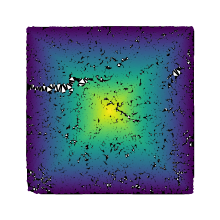

In [12]:
plt.figure(figsize=(2,2))
nx.draw(G, pos=nx.get_node_attributes(G, "pos"), node_color=d, node_size=1)
plt.axis("square")
plt.savefig("../result_plots/root_cause/dist.png")

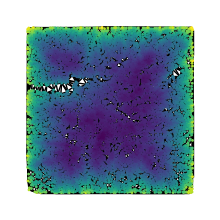

In [13]:
plt.figure(figsize=(2,2))
nx.draw(G, pos=nx.get_node_attributes(G, "pos"), node_color=C_true, node_size=1)
plt.axis("square")
plt.savefig("../result_plots/root_cause/closeness.png")

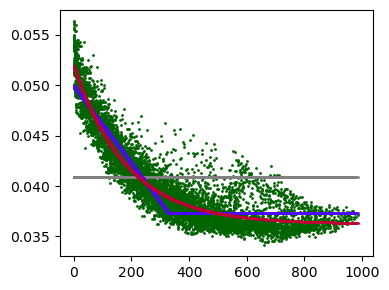

In [14]:
plt.figure(figsize=(4, 3))
plt.scatter(d, C_true, label="C_true", s=1, color="darkgreen")
plt.scatter(d, C_const, label="C_const", s=1, color=pal["const"])
plt.scatter(d, C_pieli, label="C_pieli", s=1, color=pal["pieli"])
plt.scatter(d, C_exp, label="C_exp", s=1, color=pal["exp"])
#plt.legend()
plt.tight_layout()
plt.savefig("../result_plots/root_cause/fits.svg")

In [1]:
from graph_tool.all import Graph


In [2]:
edges = [[0, 1], [2, 4], [1, 4]]
g = Graph(directed=False)
g.add_edge_list(edges)

In [7]:
for e in g.edges():
    print(e)

(0, 1)
(1, 4)
(2, 4)


In [8]:
for e in g.vertices():
    print(e)

0
1
2
3
4


In [12]:
compute_centrality_measures(edges)

{'degree': [1, 2, 1, 0, 2],
 'pagerank': [0.16909749067357968,
  0.31283022016975404,
  0.16909749067357968,
  0.03614457831333275,
  0.31283022016975404],
 'betweenness': [0.0, 0.3333333333333333, 0.0, 0.0, 0.3333333333333333],
 'closeness': [0.5, 0.75, 0.5, nan, 0.75],
 'harmonic': [0.4583333333333333, 0.625, 0.4583333333333333, 0.0, 0.625],
 'clustering': [0.0, 0.0, 0.0, 0.0, 0.0]}